Nom : 

Prénom : 

Promo : 

# Analyse de séquences de mitofusines

La mitofusine est une protéine impliquée dans la fusion de mitochondries. On va analyser ici quelques séquences (composition en acides-aminés) issues de mitofusines de levures *Saccharomyces cerevisiae*. Sur la base de données Uniprot, on a récupéré un fichier multifasta `mitofusin_saccharomyces.fasta`.

Dans la cellule suivante, importez le module `pandas` avec son alias et le module `matplotlib` avec son alias. Importer également le module `collections`.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import collections
#import matplotlib.pyplot as plt

Dans la cellule suivante, complétez la fonction `get_seqs(multifasta)` où `multifasta` (`str`) est un nom de fichier multifasta. La fonction devra renvoyer une liste avec les séquences de chaque protéine, ainsi que la liste avec les identifiants de chaque protéine. Chaque séquence et identifiant sont des `str`.

Pour rappel, dans une ligne de définition d'un fichier multifasta comme celle-ci

```
>sp|P38297|FZO1_YEAST Mitofusin FZO1 OS=Saccharomyces cerevisiae (strain ATCC 204508 / S288c) OX=559292 GN=FZO1 PE=1 SV=1
```

l'identifiant est `P38297`.

In [3]:
def get_seqs(multifasta):
    # Initialisation de listes pour les séquences et les identifiants.
    seqs = []
    ids = []
    with open(multifasta) as f:
        # Initialisation de la première séquence.
        seq = ""
        for line in f:
            if line.startswith(">"):
                # Mettez ici votre code pour récupérer
                # l'identifiant et l'ajouter à la liste ids.
                ids.append(line[4:10])
                # Récupération de la séquence précédente.
                if seq:
                    seqs.append(seq)
                # Initialisation de la prochaine séquence.
                seq = ""
            else:
                # On complète la séquence.
                seq += line.strip()
        # On a fini de lire le fichier multifasta, 
        # on ajoute la dernière séquence.
        seqs.append(seq)
    return seqs, ids

Dans la cellule suivante, appellez la fonction `get_seqs()` en lui passant le fichier multifasta comme argument, et récupèrez une liste de séquences ainsi que la liste d'identifiants de chaque protéine.

In [4]:
seqs, ids = get_seqs("mitofusin_saccharomyces.fasta")
#for protein in range(len(ids):
    

Dans la cellule suivante, créer une liste `counters` dans laquelle vous stockerez le comptage des acide-aminés de chaque protéine.

*Conseil* : la fonction `Counter()` du module `collections` est votre amie (souvenez-vous, elle ressemble à un dictionnaire 😉). La liste `counters` sera donc une liste d'objets `Counter`.

In [ ]:
counters = [collections.Counter(seq) for seq in seqs]

Ensuite, créez un dataframe pandas à partir de votre liste de compteurs avec pour index les identifiants fasta. Puis affichez les 5 premières lignes.

In [19]:
df = pd.DataFrame(counters, index=ids)
print(df)

         M    S    E   G   K   Q   F    D   N   P   H   T   A   I   V    L  \
P38297  17   72   60  33  78  37  32   60  51  34  17  45  35  60  40  109   
P39538  26   96  109  59  77  39  58  117  90  59  19  70  49  69  75  113   
Q01476  16  101  104  48  92  52  54   92  84  50  24  81  52  88  63  135   
Q05930  11   31   36  26  30  16  34   47  38  25  14  31  23  41  26   74   
G0W8W7  13   82   62  31  70  40  34   65  69  29  18  52  29  62  48   88   
A0A0J9  11   89   57  35  62  30  37   77  40  33  19  44  59  54  66   80   
A0A1V2  12   80   53  44  67  38  34   76  50  25  17  36  53  40  79   91   
A0A1V2  13   77   59  37  73  28  36   66  70  28  20  43  27  72  63   88   
A0A1X7  14   67   65  31  64  43  31   68  70  30  23  51  35  62  47   88   
A0A6C1  17   72   61  34  78  37  32   60  51  34  17  45  34  60  40  109   
A0A6C1  15   74   70  31  81  40  32   59  55  35  17  46  43  61  51  108   
A0A8B8  20   78   62  30  78  37  31   59  54  33  17  48  37  5

Affichez la colonne pour l'acide-aminé tryptophane :

In [20]:
df["W"]

P38297     5.0
P39538    13.0
Q01476     7.0
Q05930    10.0
G0W8W7     7.0
A0A0J9     2.0
A0A1V2     1.0
A0A1V2     NaN
A0A1X7     6.0
A0A6C1     5.0
A0A6C1     5.0
A0A8B8     5.0
A0A8H2     5.0
A0AA35     5.0
A0AA35     5.0
A0AA35     5.0
A5E454     NaN
A6ZLC0     5.0
B3LMY2     5.0
B5VED2     3.0
C7GUJ2     5.0
D3UES3     5.0
G0VBF7     4.0
G2W9I0     5.0
J8Q510     5.0
N1P8C8     5.0
Q75D27     9.0
Name: W, dtype: float64

Que se passe-t-il pour les protéines ne possédant pas de tryptophane ? (répondez dans la cellule ci-dessous)

Les valeurs sont indiqués comme NaN (Not a Number)

Remédiez à ce problème de manière à mettre à 0 la quantité de tryptophanes pour les protéines qui n'en ont pas. Réaffichez ensuite le dataframe.

In [21]:
df = df.fillna(0).astype(int)
df["W"]

P38297     5
P39538    13
Q01476     7
Q05930    10
G0W8W7     7
A0A0J9     2
A0A1V2     1
A0A1V2     0
A0A1X7     6
A0A6C1     5
A0A6C1     5
A0A8B8     5
A0A8H2     5
A0AA35     5
A0AA35     5
A0AA35     5
A5E454     0
A6ZLC0     5
B3LMY2     5
B5VED2     3
C7GUJ2     5
D3UES3     5
G0VBF7     4
G2W9I0     5
J8Q510     5
N1P8C8     5
Q75D27     9
Name: W, dtype: int64

Affichez les séquences qui contiennent plus de 5 tryptophanes.

In [32]:
prot5W_list = list(df[df["W"]>5].index)
print(prot5W_list)

['P39538', 'Q01476', 'Q05930', 'G0W8W7', 'A0A1X7', 'Q75D27']


Créez un nouveau dataframe `df5W` avec ces 5 séquences :

In [34]:
df5W = pd.DataFrame(df[df["W"]>5],
                    index=prot5W_list)
df5W

,M,S,E,G,K,Q,F,D,N,P,H,T,A,I,V,L,Y,R,W,C
P39538,26,96,109,59,77,39,58,117,90,59,19,70,49,69,75,113,53,44,13,19
Q01476,16,101,104,48,92,52,54,92,84,50,24,81,52,88,63,135,61,55,7,13
Q05930,11,31,36,26,30,16,34,47,38,25,14,31,23,41,26,74,32,44,10,9
G0W8W7,13,82,62,31,70,40,34,65,69,29,18,52,29,62,48,88,24,39,7,9
A0A1X7,14,67,65,31,64,43,31,68,70,30,23,51,35,62,47,88,27,43,6,9
Q75D27,11,73,59,32,56,32,29,61,51,25,19,37,43,41,57,97,25,44,9,7


Calculez la longueur en acide-aminés des séquences qui contiennent plus de 5 tryptophanes en sommant chaque ligne (pensez à l'argument `axis` 😉), et mettez la *Series* obtenue dans la variable len_df5W. Affichez cette *Series*.

In [ ]:
len_df5W = df5W.sum(axis=1)
print(len_df5W)

P39538    1254
Q01476    1272
Q05930     598
G0W8W7     871
A0A1X7     874
Q75D27     808
dtype: int64


A partir de `df5W` et `len_df5W`, calculez pour chaque protéine les fréquences de chaque acide-aminé à l'aide de la méthode `.div()` (pensez à l'argument `axis` 😉). Mettez ce nouveau dataframe dans la variable `df5W_freq` puis affichez le.

In [40]:
df5W_freq = df5W.div(len_df5W, axis=0)
print(df5W_freq)

               M         S         E         G         K         Q         F  \
P39538  0.020734  0.076555  0.086922  0.047049  0.061404  0.031100  0.046252   
Q01476  0.012579  0.079403  0.081761  0.037736  0.072327  0.040881  0.042453   
Q05930  0.018395  0.051839  0.060201  0.043478  0.050167  0.026756  0.056856   
G0W8W7  0.014925  0.094145  0.071183  0.035591  0.080367  0.045924  0.039036   
A0A1X7  0.016018  0.076659  0.074371  0.035469  0.073227  0.049199  0.035469   
Q75D27  0.013614  0.090347  0.073020  0.039604  0.069307  0.039604  0.035891   

               D         N         P         H         T         A         I  \
P39538  0.093301  0.071770  0.047049  0.015152  0.055821  0.039075  0.055024   
Q01476  0.072327  0.066038  0.039308  0.018868  0.063679  0.040881  0.069182   
Q05930  0.078595  0.063545  0.041806  0.023411  0.051839  0.038462  0.068562   
G0W8W7  0.074627  0.079219  0.033295  0.020666  0.059701  0.033295  0.071183   
A0A1X7  0.077803  0.080092  0.034325  0

Faites un barplot de la fréquence en leucine pour ces séquences contenant plus de 5 tryptophanes. Pensez à la méthode `series.plot.bar()` 😉 (où vous remplacerez `series` par votre objet *Series*).

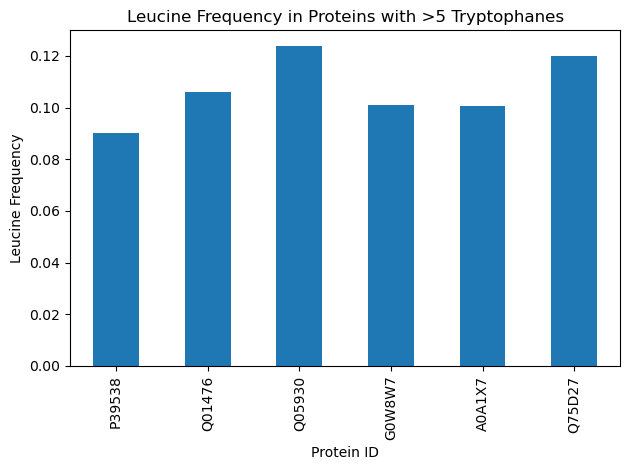

In [49]:
df5W_freq["L"].plot.bar()
plt.xlabel("Protein ID")
plt.ylabel("Leucine Frequency")
plt.title("Leucine Frequency in Proteins with >5 Tryptophanes")
plt.tight_layout()
plt.show()